In [1]:
import numpy as np, pandas as pd


timeindex = pd.date_range(start='2025-01-01',end='2025-01-31', freq='30min',inclusive='left')

A = np.random.normal(loc=0, scale=1, size=timeindex.shape[0])
B = 2 * A + np.random.normal(loc=0, scale=1, size=len(A))


dataA = pd.DataFrame(data=dict(A=A, B=B),index=timeindex)

dataA

,A,B
2025-01-01 00:00:00,0.168441,-2.622818
2025-01-01 00:30:00,-1.410633,-2.566026
2025-01-01 01:00:00,2.039583,4.137227
2025-01-01 01:30:00,-1.249752,-2.432881
2025-01-01 02:00:00,-1.482960,-2.344458
...,...,...
2025-01-30 21:30:00,2.177821,4.912198
2025-01-30 22:00:00,-1.300245,-1.545776
2025-01-30 22:30:00,0.651997,0.467259
2025-01-30 23:00:00,0.665655,1.894418


In [ ]:
data1_pivot = dataA.copy()


C = data1_pivot['B'].sum(axis=1)
C = 3 * C + np.random.normal(loc=0, scale=1, size=len(C))

C2 = data1_pivot['B'].max(axis=1)

D = 4 * C + + np.random.normal(loc=0, scale=1, size=len(C))
E = np.cumsum(C)
dataB = pd.DataFrame(data=dict(C=C, D=D, E=E))
dataB

,C,D,E
date,,,
2025-01-01,-0.585665,-2.603729,-0.585665
2025-01-02,25.481054,102.033777,24.895389
2025-01-03,31.829108,126.613736,56.724497
2025-01-04,-17.972990,-73.399306,38.751507
2025-01-05,-72.138560,-287.379156,-33.387053
2025-01-06,34.874870,141.584476,1.487816
2025-01-07,-46.538481,-187.612127,-45.050665
2025-01-08,-11.886198,-49.151283,-56.936863
2025-01-09,10.893681,42.399712,-46.043182


## Step 1: Modeling cause-effect relationships as a structural causal model (SCM)

The first step is to model the cause-effect relationships between variables relevant to our use case. We do that in form of a causal graph. A causal graph is a directed acyclic graph (DAG) where an edge X→Y implies that X causes Y. Statistically, a causal graph encodes the conditional independence relations between variables. Using the [NetworkX](https://networkx.org/) library, we can create causal graphs. In the snippet below, we create a chain X→Y→Z:



In [3]:
import networkx as nx
causal_graphA = nx.DiGraph([('A', 'B')])
causal_graphB = nx.DiGraph([('C', 'D'),('D','E')])

To answer causal questions using causal graphs, we also have to know the nature of underlying data-generating process of variables. A causal graph by itself, being a diagram, does not have any information about the data-generating process. To introduce this data-generating process, we use an SCM that’s built on top of our causal graph:


In [4]:
from dowhy import gcm

causal_modelA = gcm.StructuralCausalModel(causal_graphA)
causal_modelB = gcm.StructuralCausalModel(causal_graphB)

In [5]:
from dowhy.gcm.defined_causal_mechanisms import DefinedConditionalStochasticModel


causal_modelB.set_causal_mechanism("E",DefinedConditionalStochasticModel(lambda x: np.cumsum(x)))

In [6]:
auto_assignment_summaryA = gcm.auto.assign_causal_mechanisms(causal_modelA, based_on=dataA,experimental_allow_nans=True)
auto_assignment_summaryB = gcm.auto.assign_causal_mechanisms(causal_modelB, based_on=dataB,experimental_allow_nans=True)

Optionally, we can get more insights from the auto assignment process:

In the real world, the data comes as an opaque stream of values, where we typically don't know how one
variable influences another. The graphical causal models can help us to deconstruct these causal
relationships again, even though we didn't know them before.

## Step 2: Fitting the SCM to the data

With the data at hand and the graph constructed earlier, we can now train the SCM using `fit`:

In [7]:
gcm.fit(causal_modelA, dataA)
gcm.fit(causal_modelB, dataB)

Fitting causal mechanism of node E: 100%|██████████| 3/3 [00:00<00:00, 336.00it/s]


Fitting means, we learn the generative models of the variables in the SCM according to the data.

Once fitted, we can also obtain more insights into the model performances:

Test permutations of given graph: 100%|██████████| 2/2 [00:00<00:00, 1416.76it/s]


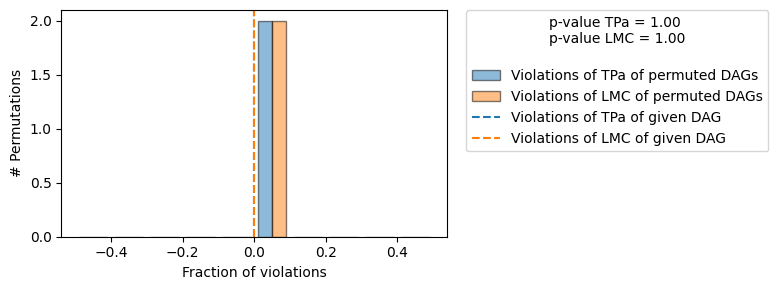

Evaluated the performance of the causal mechanisms and the invertibility assumption of the causal mechanisms and the overall average KL divergence between generated and observed distribution and the graph structure. The results are as follows:

==== Evaluation of Causal Mechanisms ====
The used evaluation metrics are:
- KL divergence (only for root-nodes): Evaluates the divergence between the generated and the observed distribution.
- Mean Squared Error (MSE): Evaluates the average squared differences between the observed values and the conditional expectation of the causal mechanisms.
- Normalized MSE (NMSE): The MSE normalized by the standard deviation for better comparison.
- R2 coefficient: Indicates how much variance is explained by the conditional expectations of the mechanisms. Note, however, that this can be misleading for nonlinear relationships.
- F1 score (only for categorical non-root nodes): The harmonic mean of the precision and recall indicating the goodness of the under

In [8]:
print(gcm.evaluate_causal_model(causal_modelA, dataA))

Test permutations of given graph: 100%|██████████| 6/6 [00:02<00:00,  2.84it/s]


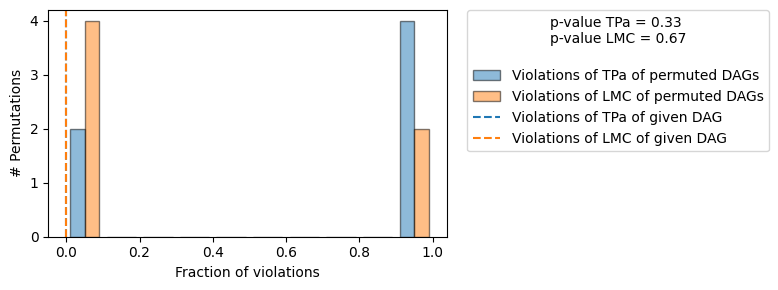

Evaluated the performance of the causal mechanisms and the invertibility assumption of the causal mechanisms and the overall average KL divergence between generated and observed distribution and the graph structure. The results are as follows:

==== Evaluation of Causal Mechanisms ====
The used evaluation metrics are:
- KL divergence (only for root-nodes): Evaluates the divergence between the generated and the observed distribution.
- Mean Squared Error (MSE): Evaluates the average squared differences between the observed values and the conditional expectation of the causal mechanisms.
- Normalized MSE (NMSE): The MSE normalized by the standard deviation for better comparison.
- R2 coefficient: Indicates how much variance is explained by the conditional expectations of the mechanisms. Note, however, that this can be misleading for nonlinear relationships.
- F1 score (only for categorical non-root nodes): The harmonic mean of the precision and recall indicating the goodness of the under

In [9]:
print(gcm.evaluate_causal_model(causal_modelB, dataB))

In [12]:
from dowhy.gcm.defined_causal_mechanisms import AggregationMechanism


links = {
    ("B", "C"): AggregationMechanism(
        aggregation_function="sum"
    ),
    ("B", "C2"): AggregationMechanism(
         aggregation_function="max"
    )
}

In [13]:
causal_model_composite = gcm.StructuralCausalModelComposite(
    [causal_modelA, causal_modelB], links=links
)

ValueError: not enough values to unpack (expected 3, got 2)

## Step 3: Answering a causal query based on the SCM

The last step, answering a causal question, is our actual goal. E.g. we could ask the question "What will happen to the variable Z if I intervene on Y?".

This can be done via the `interventional_samples` function. Here’s how:

In [ ]:
samples = gcm.interventional_samples(causal_model_composite,
                                     {'B': lambda B: B },
                                    observed_data= dataA[["A"]])
samples

{'A': array([-0.54087977, -0.81841385, -0.06710148, ..., -0.22533216,
         2.27080179,  0.1539185 ]),
 'B': array([-0.17098686, -0.97750189,  1.04444806, ..., -0.76420809,
         4.8541394 , -0.0800229 ]),
 'C': array([  3.49910537, -14.814814  ,  -1.0840187 ,   8.87514054,
          1.6657768 ,  -2.64071781,   6.81236158,  -7.01588357,
          5.81098114,  -0.31047739,  -0.33052032,  -9.64594845,
          8.33511784,  -0.14143208,  -0.71863894,  -0.79014001,
         -1.24300481,   1.71424768,   0.26505628,  -1.19369474,
         24.88272412,   0.18671076,   9.48251572,   4.40239019,
          2.30147604,   2.153417  ,   5.88568592,   5.63706881,
         15.06044039,   2.41014003]),
 'C2': array([array([[-0.29259861,  0.76583653,  0.5135981 ,  1.        ,  0.36947754,
                 1.6446133 ,  1.        ,  4.        ,  0.01134216,  4.        ,
                 0.18837397,  1.        ,  1.        ,  0.08333333,  0.08333333,
                 0.02162012,  5.        ,  2.091